In [ ]:
import pandas as pd

df = pd.read_csv("../../full_prompt_test/summary.csv")

df

,model_name,prompt_name,BLEU,ROUGE-L,JSD,Jaccard,Levenshtein,BERTScore
0,m0,p1,0.000000e+00,0.000000,0.167445,0.000000,0.128201,0.318934
1,m0,p2,0.000000e+00,0.048718,0.167445,0.000000,0.032591,0.313527
2,m0,p3,4.813279e-03,0.100000,0.221128,0.066667,0.202363,0.395768
3,m0,p4,0.000000e+00,0.000000,0.167445,0.000000,0.588889,0.770801
4,m0,p5,0.000000e+00,0.000000,0.167445,0.000000,0.177375,0.427256
5,m0,icl_p6,1.422624e-01,1.000000,0.833489,0.800000,0.933333,0.924076
6,m0,icl_p7,0.000000e+00,0.000000,0.167445,0.000000,0.123511,0.316753
7,m0,icl_p8,7.113118e-02,0.444444,0.500467,0.400000,0.418605,0.734446
8,m2,p1,0.000000e+00,0.000000,0.167445,0.000000,0.604332,0.748037
9,m2,p2,6.514065e-04,0.066667,0.203909,0.040000,0.057017,0.341477


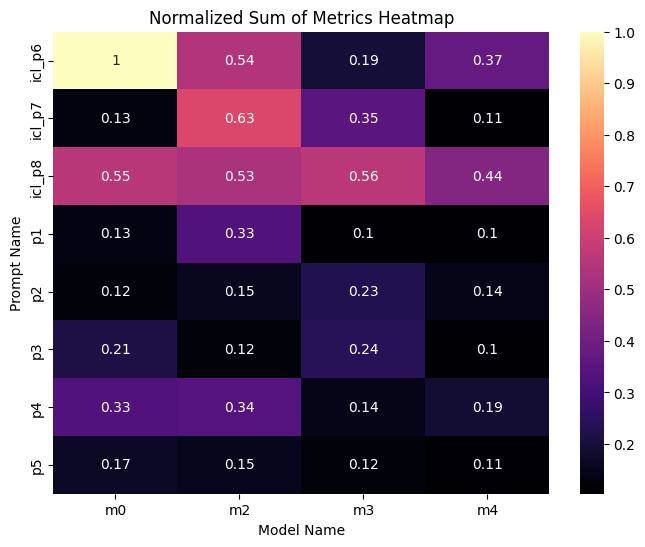

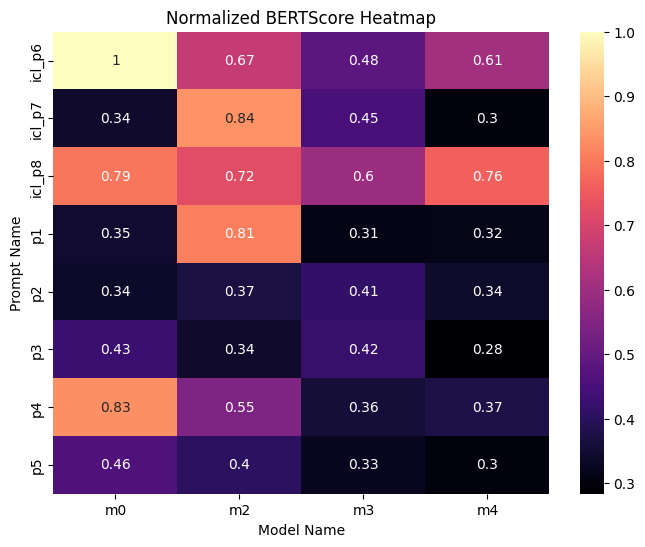

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your loaded dataframe
# Sum of all metric columns (excluding model_name and prompt_name)
metric_cols = ['BLEU', 'ROUGE-L', 'JSD', 'Jaccard', 'Levenshtein', 'BERTScore']
df['sum_metrics'] = df[metric_cols].sum(axis=1)

# --- 1️⃣ Heatmap for sum of metrics ---
sum_pivot = df.pivot(index='prompt_name', columns='model_name', values='sum_metrics')
# Normalize to 0–1 by dividing by the max
sum_pivot_norm = sum_pivot / sum_pivot.max().max()

plt.figure(figsize=(8, 6))
sns.heatmap(sum_pivot_norm, annot=True, cmap='magma')
plt.title("Normalized Sum of Metrics Heatmap")
plt.xlabel("Model Name")
plt.ylabel("Prompt Name")
plt.show()

# --- 2️⃣ Heatmap for BERTScore ---
bert_pivot = df.pivot(index='prompt_name', columns='model_name', values='BERTScore')
# Normalize to 0–1 by dividing by the max
bert_pivot_norm = bert_pivot / bert_pivot.max().max()

plt.figure(figsize=(8, 6))
sns.heatmap(bert_pivot_norm, annot=True, cmap='magma')
plt.title("Normalized BERTScore Heatmap")
plt.xlabel("Model Name")
plt.ylabel("Prompt Name")
plt.show()


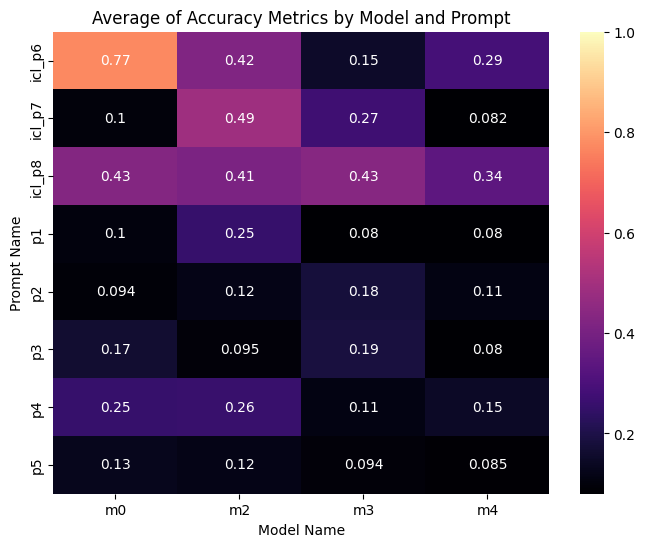

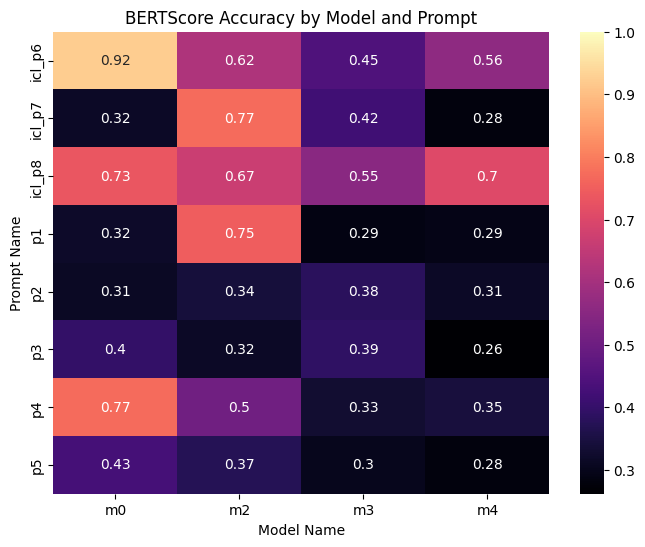

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is already loaded
metric_cols = ['BLEU', 'ROUGE-L', 'JSD', 'Jaccard', 'Levenshtein', 'BERTScore']
df['avg_metrics'] = df[metric_cols].mean(axis=1)

# --- 1️⃣ Heatmap for sum of metrics ---
avg_pivot = df.pivot(index='prompt_name', columns='model_name', values='avg_metrics')

plt.figure(figsize=(8, 6))
sns.heatmap(avg_pivot, annot=True, cmap='magma', vmin=avg_pivot.min().min(), vmax=1)
plt.title("Average of Accuracy Metrics by Model and Prompt")
plt.xlabel("Model Name")
plt.ylabel("Prompt Name")
plt.show()

# --- 2️⃣ Heatmap for BERTScore ---
bert_pivot = df.pivot(index='prompt_name', columns='model_name', values='BERTScore')

plt.figure(figsize=(8, 6))
sns.heatmap(bert_pivot, annot=True, cmap='magma', vmin=bert_pivot.min().min(), vmax=1)
plt.title("BERTScore Accuracy by Model and Prompt")
plt.xlabel("Model Name")
plt.ylabel("Prompt Name")
plt.show()
